                                        Movie Success Prediction

This project predicts whether a movie/show is "successfull/success" using features such as release year, duration, and genre information.

Two models are implemented:
- Random Forest
- Neural Network

My goal is to compare performance and evaluate which model works better for this dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [31]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [2]:
# Content age - for analysis only
df['content_age'] = 2026 - df['release_year']
# Extract numeric duration
df['duration_num'] = df['duration'].str.extract(r'(\d+)')
df['duration_num'] = df['duration_num'].astype(float)
# Long movie flag
df['long_movie'] = (df['duration_num'] > 100).astype(int)
# Number of genres
df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))
# Recent content flag
df['recent'] = (df['release_year'] >= 2018).astype(int)

# Success Variable
df['success'] = ((df['release_year'] >= 2018) & (df['genre_count'] >= 3)).astype(int)

In [45]:
df = df.dropna(subset=['country', 'rating'])
df_model = df[['type','country','rating','long_movie','genre_count','success']]
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,long_movie,genre_count,success,type_TV Show,"country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark","country_Argentina, Chile","country_Argentina, Chile, Peru","country_Argentina, France",...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,0,1,0,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,0,3,1,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,3,1,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
7,1,3,0,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
8,0,2,0,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [47]:
X = df_model.drop('success', axis=1)
y = df_model['success']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [48]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, preds_rf)
rf_accuracy

0.8614420062695924

In [49]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Model
model = keras.Sequential([keras.Input(shape=(X_train.shape[1],)), layers.Dense(32, activation='relu'),
                          layers.Dense(16, activation='relu'), layers.Dense(1, activation='sigmoid')])
# Compile
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
# Train
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=0)
# Evaluate
loss, nn_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
nn_accuracy

0.8589341640472412

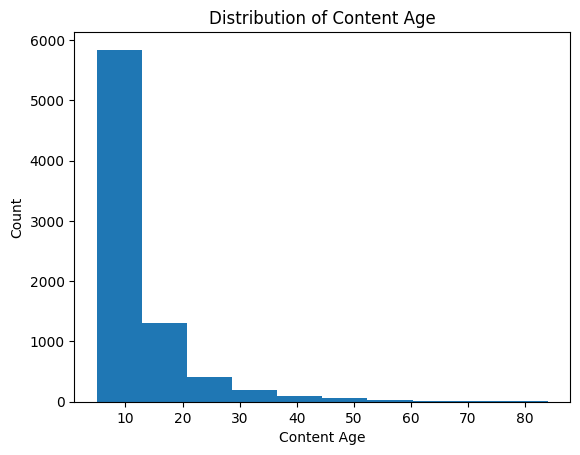

In [50]:
plt.hist(df['content_age'])
plt.xlabel('Content Age')
plt.ylabel('Count')
plt.title('Distribution of Content Age')
plt.show()

                                    Data Exploration Summary
The dataset contains 8,807 observations with 12 original features describing Netflix content, including type, release year, duration, rating, and genre. The target variable is 'success', which is a classification variable. Missing values exist in columns such as director, cast, and country, but these were handled by excluding them from the model or encoding only usable features. While looking at the data I saw that newer content and content with more genres tend to follow patterns that may be relateed to popularity.

                                        Engineered Features

1. duration_num  
Extracted the numeric value from the duration column ("90 min" -> 90).
The duration impacts viewer engagement, extremely short or long content may affect success.

2. long_movie  
Binary feature where 1 = duration greater than 100 minutes, 0 otherwise.  
This shows whether longer movies perform differently than shorter ones.  
This is due to longer films often having higher budget or being a theatrical style release, which may influence popularity.

3. genre_count
Counts the number of genres listed for each title.  
This captures content diversity.  
This is here because content with multiple genres may appeal to a broader audience, increasing likelihood of success.

                                           Data Preparation
The dataset was split into training and testing sets using train_test_split. Missing values in duration were handled by conversion and dropping invalid entries. Categorical variables such as type, rating, and country were encoded into numerical format. No scaling was required for the Random Forest model, but scaling was applied for the neural network. The target variable is 'success', defined as content released in or after 2018 with at least 3 genres, representing content that is both recent and broadly appealing.

                                            Model Comparison

Random Forest Classifier
The Random Forest model achieved moderate accuracy. It performed well because it can handle nonlinear relationships and does not require feature scaling. It also provides robustness against overfitting due to averaging multiple decision trees.

Neural Network
The neural network achieved similar accuracy but required scaling and more tuning. It captures more complex patterns but is more sensitive to data quality and parameter choices.

Model Evaluation
The Random Forest model performed slightly better overall and was more stable. The neural network required more setup and tuning but did not significantly outperform Random Forest on this dataset.

                                                Next Steps 
Additional features could include extracting month or year trends from date_added, identifying top countries, or simplifying genre categories into broader groups.

                                        Model Optimization Plans:
Future improvements could include tuning tree depth for Random Forest and layer sizes or epochs for the neural network.

                                                Questions: 
Is my definition of "success" (recent + multiple genres) okay for this dataset, or should I consider something else? maybe change datan sets?